In [1]:
import collections
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm

random.seed(1234)
np.random.seed(1234)
torch.manual_seed(1234)
print("numpy: ", np.__version__)
print("pandas: ", pd.__version__)
print("torch: ", torch.__version__)

numpy:  2.0.2
pandas:  2.2.2
torch:  2.9.0+cu126


In [2]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# 環境向けのパラメータ
DAYS = 90  # 作成するサンプルデータは3ヶ月分とする
HOURS = 8  # 1営業日の稼働時間は8時間とする
MIN_OPERATORS = 14  # 最小オペレータ人数
MAX_OPERATORS = 18  # 最大オペレータ人数
DELTA_OPERATOR = MAX_OPERATORS - MIN_OPERATORS  # Actorの出力(-1～1)のスケール変更で用いる
PRICE_PER_CALL = 1200  # パーコール単価
COST_PER_OPERATOR = 24000  # オペレータ1人の1日あたりの人件費と経費
PENALTY_PER_UNHANDLED_CALL = 1500  # 報酬の計算で用いる # 対応出来なかった問い合わせ1件毎に課すペナルティ
MAX_CALLS_PER_DAY = 550  # 1日の問い合わせ数の基準
# ロジック向けのパラメータ
STATE_DIM = 3  # 状態は(正規化した問い合わせ数, 対応した問い合わせ数の割合, オペレータの問い合わせ対応時間の割合)とする想定
ACTION_DIM = 1  # 1ステップで取り得る行動の数 # 本件は価格を1つ選択する行動なので1になる
REPLAY_BUFFER_MAX_SIZE = 50000
MINIBATCH_SIZE = 16
GAMMA = 0.99  # 報酬の割引率(CriticのSACの損失値で使う)
ALPHA = 2  # Actorの損失値でのエントロピー項の重み
TAU = 0.005  # ターゲットCriticのパラメータを更新する時の学習率
CQL_RANDOM_ACTION_TIMES = 10  # conservative補正項を算出する際に1ミニバッチ(1状態)あたりにランダム取得した行動を何回行うか
CQL_ALPHA = 1  # CQL正則化項の強さ(1～10) # 大きいとconservativeで安全寄り
UPDATE_CRITIC_TIMES = 2  # Actorを1回学習する前にCriticを何回学習するか
UPDATE_TIMES_PER_EPISODE = 3  # 何回学習したら1エピソードとするか

経験バッファに保存する用のサンプルデータを作成<br>⇒題目はパーコールのコールセンター受託案件<br>⇒日毎のオペレータ配置人数、問い合わせ数、問い合わせ対応数、合計稼働時間、合計対応時間、利益

In [3]:
data_list = []
for day in range(DAYS):
    # 行動: 1日のオペレータ増減人数
    n_operator = np.random.randint(low=MIN_OPERATORS,  # 1日のオペレータ人数(最小人数～最大人数でランダム取得)
                                   high=MAX_OPERATORS + 1)
    if day == 0:
        previous_n_operator = n_operator
    delta_n_operator = n_operator - previous_n_operator
    previous_n_operator = n_operator  # 次のループで用いるため
    # 状態: 1日の合計稼働時間(秒)
    working_seconds = n_operator * HOURS * 3600
    # 状態: 1日の問い合わせ数(最大問い合わせ数の85%～最大問い合わせ数でランダム取得)
    daily_calls = np.random.randint(low=int(0.85 * MAX_CALLS_PER_DAY),
                                    high=MAX_CALLS_PER_DAY)
    # 状態: 1日の問い合わせ対応数
    average_time_per_call = np.random.uniform(low=600,  # 1問い合わせあたりの平均対応時間(600秒～1200秒を一様分布でランダム取得)
                                              high=1200)
    capacity = working_seconds / average_time_per_call  # 「合計稼働時間」÷「平均対応時間」で1日の対応可能な問い合わせ数
    handled_calls = min(daily_calls,  # 「1日の問い合わせ数」と「1日の対応可能な問い合わせ数」の小さい方を「対応した問い合わせ数」
                        int(capacity))
    # 状態: 1日の合計対応時間(秒)
    operating_seconds = int(average_time_per_call * handled_calls)
    # 報酬: 売上(対応した問い合わせ) － 費用(オペレータの人件費) － ペナルティ(未対応問い合わせ数)
    benefit = handled_calls * PRICE_PER_CALL - n_operator * COST_PER_OPERATOR - (daily_calls - handled_calls) * PENALTY_PER_UNHANDLED_CALL
    # それぞれのデータを保存
    data_list.append({
        "day": day + 1,
        "operators": n_operator,
        "delta_operators": delta_n_operator,
        "daily_calls": daily_calls,
        "handled_calls": handled_calls,
        "working_seconds": working_seconds,
        "operating_seconds": operating_seconds,
        "benefit": benefit,
        "averate_time_per_call": average_time_per_call
    })
df = pd.DataFrame(data=data_list)

In [4]:
class MyActor(torch.nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.layer_1 = torch.nn.Linear(in_features=state_dim,
                                       out_features=64)
        self.layer_2_mu = torch.nn.Linear(in_features=64,
                                          out_features=action_dim)  # 確率分布は行動毎になるので、行動毎のmuを出力する
        self.layer_2_log_sigma = torch.nn.Linear(in_features=64,
                                                 out_features=action_dim)  # 確率分布は行動毎になるので、行動毎のlog_sigmaを出力する

    def forward(self, in_data):
        out_layer_1 = torch.nn.functional.relu(self.layer_1(in_data))
        out_layer_2_mu = self.layer_2_mu(out_layer_1)
        out_layer_2_log_sigma = self.layer_2_log_sigma(out_layer_1)
        return out_layer_2_mu, out_layer_2_log_sigma

    def get_action(self, in_data_state_tensor):
        mu, log_sigma = self.forward(in_data=in_data_state_tensor)
        log_sigma = torch.clamp(input=log_sigma,  # 論文ではlogσを発散させないために-20～2でクリッピングしている
                                min=-20,
                                max=2)
        sigma = torch.exp(log_sigma)  # sigmaを必ずプラスの値にするために、ニューラルネットワークモデルからの出力はlog_sigmaとして、それにexpを行ってsigmaにする
        epsilon = torch.randn_like(sigma)  # reparameterization trickでepsilonに掛けるのはsigmaなので、sigmaを引数にしてepsilonを作れば確実に同じ次元になる
        sampling = mu + sigma * epsilon  # Actorが出力したmuとsigmaの正規分布からのサンプリング # reparameterization trick
        continuous_action = torch.tanh(sampling)  # SACでは取り得る行動は-1～1の連続値とする
        policy = torch.distributions.Normal(loc=mu,  # Actorが出力したmuとsigmaで正規分布を作成(方策π(S)になる)
                                            scale=sigma)
        sampling_log_prob = policy.log_prob(value=sampling)  # logπ(A|S)
        continuous_action_log_prob = sampling_log_prob - torch.log(1 - continuous_action.pow(2) + 1e-6)  # samplingでの確率をtanh(sampling)での確率とみなすためにlogπ(A|S)をヤコビアン補正する
        continuous_action_log_prob_scalar = continuous_action_log_prob.sum(dim=-1,  # 行動が複数の場合は多次元ベクトルになって損失値計算で扱えないので、同時確率にしてスカラー値にするにあたり、
                                                                           keepdim=True)  # 行動毎の確率分布は独立なので同時確率は総積になるところ、logにしているので総和になる
        return continuous_action, continuous_action_log_prob_scalar


class MyCritic(torch.nn.Module):
    def __init__(self, state_dim, action_dim):  # Soft Actor CriticではCriticは行動価値を出力する形になる
        super().__init__()
        self.layer_1 = torch.nn.Linear(in_features=state_dim + action_dim,
                                       out_features=64)
        self.layer_2 = torch.nn.Linear(in_features=64,
                                       out_features=1)

    def forward(self, in_data_state, in_data_action):
        in_data = torch.cat(tensors=[in_data_state, in_data_action],
                            dim=-1)
        out_layer_1 = torch.nn.functional.relu(self.layer_1(in_data))
        out_layer_2 = self.layer_2(out_layer_1)
        return out_layer_2


class MyDoubleCritic(torch.nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.critic_model_1 = MyCritic(state_dim=state_dim,
                                       action_dim=action_dim)
        self.critic_model_2 = MyCritic(state_dim=state_dim,
                                       action_dim=action_dim)

    def forward(self, in_data_state_tensor, in_data_action_tensor):
        out_critic_model_1 = self.critic_model_1(in_data_state=in_data_state_tensor,
                                                 in_data_action=in_data_action_tensor)
        out_critic_model_2 = self.critic_model_2(in_data_state=in_data_state_tensor,
                                                 in_data_action=in_data_action_tensor)
        return out_critic_model_1, out_critic_model_2

In [5]:
class ReplayBuffer():
    def __init__(self, max_queue_size):
        self.replay_buffer = collections.deque(maxlen=max_queue_size)

    def __len__(self):
        return len(self.replay_buffer)

    def add_data(self, state, action, reward, next_state, done):
        data = (state, action, reward, next_state, done)
        self.replay_buffer.append(data)  # タプルを1要素として経験バッファ(deque)に保存する

    def get_batch_data(self, batch_size):
        batch_data_list = random.sample(population=self.replay_buffer,  # 経験バッファからbatch_sizeの数だけランダムに要素を取り出す
                                        k=batch_size)  # 取り出した結果は、要素はタプルの形のリストになる
        state_tuple, action_tuple, reward_tuple, next_state_tuple, done_tuple = zip(*batch_data_list)  # zipは縦方向でデータをタプルに纏める
        state_array = np.array(state_tuple)
        action_array = np.array(action_tuple)
        reward_array = np.array(reward_tuple)
        next_state_array = np.array(next_state_tuple)
        done_array = np.array(done_tuple)
        return state_array, action_array, reward_array, next_state_array, done_array

    def get_data(self, target_index):
        return self.replay_buffer[target_index]

In [6]:
def update_actor(replay_buffer, batch_size):
    state, _, _, _, _ = replay_buffer.get_batch_data(batch_size=batch_size)
    state_tensor = torch.Tensor(state).squeeze(dim=1)  # (バッチ数N, 2)
    # 「改めての行動」と「改めての行動のlog確率」を改めて取得する
    revised_action_tensor, log_pi_revised_action_tensor = nn_actor_model.get_action(in_data_state_tensor=state_tensor.to(DEVICE))
    revised_action_tensor = DELTA_OPERATOR * revised_action_tensor  # -1～1のスケールを変える # 連続値のままでないと誤差逆伝播でエラーになる # 整数値に丸めるのは推論時だけ
    # 「改めての行動価値」を2つ出力する
    critic_revised_q_1_tensor, critic_revised_q_2_tensor = nn_double_critic_model(in_data_state_tensor=state_tensor.to(DEVICE),
                                                                                  in_data_action_tensor=revised_action_tensor)
    # 「改めての行動価値」の小さい方を得る
    critic_revised_q_min_tensor = torch.min(input=critic_revised_q_1_tensor,
                                            other=critic_revised_q_2_tensor)
    # Actorの損失値を得る
    # 目的関数は Jπ=Est∼D,at∼π[Q(st,at)+α*−logπ(a∣s)] となり、
    # Q(st,at) はCriticが予測した行動価値(報酬に関するもの)
    # −logπ(a∣s) は方策のエントロピー(ランダム性の尺度)
    # α はエントロピーの重み
    # 損失関数は目的関数の逆符号になるので Lπ=Es∼D[−Q(s,a)+α*logπ(a∣s)]
    loss_actor = - critic_revised_q_min_tensor.to("cpu") + ALPHA * log_pi_revised_action_tensor.to("cpu")  # (バッチ数N, 1)
    loss_actor_scalar = loss_actor.mean()  # 平均を取ってスカラー値にする
    # Actorを更新する
    actor_optimizer.zero_grad()
    loss_actor_scalar.backward()
    actor_optimizer.step()
    return None

In [7]:
def calc_sac_loss(replay_buffer, batch_size):
    state, action, reward, next_state, done = replay_buffer.get_batch_data(batch_size=batch_size)
    state_tensor = torch.Tensor(state).squeeze(dim=1)  # (バッチ数N, 2)
    action_tensor = torch.Tensor(action)  # (バッチ数N, 1)
    reward_tensor = torch.Tensor(reward)  # (バッチ数N, 1)
    next_state_tensor = torch.Tensor(next_state).squeeze(dim=1)  # (バッチ数N, 2)
    done_tensor = torch.Tensor(done).unsqueeze(dim=1)  # (バッチ数N, 1)
    # 「次の行動」と「次の行動のlog確率」を取得する
    next_action_tensor, log_pi_next_action_tensor = nn_actor_model.get_action(in_data_state_tensor=next_state_tensor.to(DEVICE))
    next_action_tensor = DELTA_OPERATOR * next_action_tensor  # -1～1のスケールを変える # 連続値のままでないと誤差逆伝播でエラーになる # 整数値に丸めるのは推論時だけ
    # 「次の行動価値」を2つ出力する # 正解データになるものなのでターゲットCriticで出力する
    critic_next_q_1_tensor, critic_next_q_2_tensor = nn_target_double_critic_model(in_data_state_tensor=next_state_tensor.to(DEVICE),
                                                                                   in_data_action_tensor=next_action_tensor)
    # 「次の行動価値」の小さい方を得る
    critic_next_q_min_tensor = torch.min(input=critic_next_q_1_tensor,
                                         other=critic_next_q_2_tensor)
    # ターゲットQを算出する
    target_q = reward_tensor + GAMMA * (critic_next_q_min_tensor.to("cpu") - ALPHA * log_pi_next_action_tensor.to("cpu")) * (1 - done_tensor)
    target_q_detach = target_q.to("cpu").detach()
    # 「行動価値」を2つ出力する
    critic_q_1_tensor, critic_q_2_tensor = nn_double_critic_model(in_data_state_tensor=state_tensor.to(DEVICE),
                                                                  in_data_action_tensor=action_tensor.to(DEVICE))
    # SACの損失値を算出する
    loss_critic_sac = (critic_q_1_tensor.to("cpu") - target_q_detach)**2 + (critic_q_2_tensor.to("cpu") - target_q_detach)**2  # (バッチ数N, 1)
    loss_critic_sac_scalar = loss_critic_sac.mean()  # 平均を取ってスカラー値にする
    return loss_critic_sac_scalar


def calc_cql_loss(replay_buffer, batch_size):
    state, action, _, _, _ = replay_buffer.get_batch_data(batch_size=batch_size)
    state_tensor = torch.Tensor(state).squeeze(dim=1)  # (バッチ数N, 2)
    action_tensor = torch.Tensor(action)  # (バッチ数N, 1)
    # 複数のランダムサンプリングで得た行動から価値を算出する
    random_actions_tensor = torch.empty(size=(MINIBATCH_SIZE, CQL_RANDOM_ACTION_TIMES, ACTION_DIM)).uniform_(-1, 1)
    random_actions_tensor = DELTA_OPERATOR * random_actions_tensor  # -1～1のスケールを変える # 連続値のままでないと誤差逆伝播でエラーになる # 整数値に丸めるのは推論時だけ
    state_repeat_tensor = state_tensor.unsqueeze(dim=1).repeat(1, 10, 1)  # (16, 2)テンソルを(16, 1, 2)テンソルにして(16, 10, 2)テンソルにする
    critic_q_random_1_tensor, critic_q_random_2_tensor = nn_double_critic_model(in_data_state_tensor=state_repeat_tensor.to(DEVICE),
                                                                                in_data_action_tensor=random_actions_tensor.to(DEVICE))
    critic_q_random_tensor = torch.min(input=critic_q_random_1_tensor,
                                       other=critic_q_random_2_tensor)
    critic_q_random_logsumexp = torch.logsumexp(input=critic_q_random_tensor,
                                                dim=1)  # 複数のランダムサンプリングの軸に対してsum
    critic_q_random_scalar = critic_q_random_logsumexp.to("cpu").mean()  # ミニバッチの軸に対してmean
    # Actorで得た行動から価値を算出する
    actor_action_tensor, _ = nn_actor_model.get_action(in_data_state_tensor=state_tensor.to(DEVICE))
    actor_action_tensor = DELTA_OPERATOR * actor_action_tensor  # -1～1のスケールを変える # 連続値のままでないと誤差逆伝播でエラーになる # 整数値に丸めるのは推論時だけ
    critic_q_actor_1_tensor, critic_q_actor_2_tensor = nn_double_critic_model(in_data_state_tensor=state_tensor.to(DEVICE),
                                                                              in_data_action_tensor=actor_action_tensor)
    critic_q_actor_tensor = torch.min(input=critic_q_actor_1_tensor,
                                      other=critic_q_actor_2_tensor)
    critic_q_actor_scalar = critic_q_actor_tensor.to("cpu").mean()
    # 経験バッファで得た行動から価値を算出する
    critic_q_buffer_1_tensor, critic_q_buffer_2_tensor = nn_double_critic_model(in_data_state_tensor=state_tensor.to(DEVICE),
                                                                                in_data_action_tensor=action_tensor.to(DEVICE))
    critic_q_buffer_tensor = torch.min(input=critic_q_buffer_1_tensor,
                                       other=critic_q_buffer_2_tensor)
    critic_q_buffer_scalar = critic_q_buffer_tensor.to("cpu").mean()
    # CQLの損失値を算出する
    # L_cql = α_cql * ( E_{a~μ}[Q(s, a)] - E_{a~D}[Q(s, a)] )
    # μは高Q値の行動分布(ランダム行動と方策行動)、Dは経験バッファのデータ分布
    loss_critic_cql_scalar = CQL_ALPHA * (critic_q_random_scalar + critic_q_actor_scalar - critic_q_buffer_scalar)
    return loss_critic_cql_scalar


def update_critic(replay_buffer, batch_size):
    # SACの損失値を得る
    loss_critic_sac_scalar = calc_sac_loss(replay_buffer=replay_buffer,
                                           batch_size=batch_size)
    # CQLの損失値を得る
    loss_critic_cql_scalar = calc_cql_loss(replay_buffer=replay_buffer,
                                           batch_size=batch_size)
    # Criticの損失値を得る
    loss_critic_scalar = loss_critic_sac_scalar + loss_critic_cql_scalar
    # Criticを更新する
    double_critic_optimizer.zero_grad()
    loss_critic_scalar.backward()
    double_critic_optimizer.step()
    return None

In [8]:
def update_target_critic(update_model, source_model, tau):
    # ターゲットCriticのパラメータの更新は、Criticのパラメータを引用する形で更新する
    for update_model_param, source_model_param in zip(update_model.parameters(), source_model.parameters()):
        # 変数tauは学習率みたいなもの
        calculated_param = (tau * source_model_param.data) + ((1 - tau) * update_model_param.data)
        update_model_param.data.copy_(calculated_param)
    return update_model

In [9]:
replay_buffer = ReplayBuffer(max_queue_size=REPLAY_BUFFER_MAX_SIZE)
for i in range(DAYS - 1):
    day = df.loc[i, "day"]
    delta_operator = df.loc[i, "delta_operators"]
    daily_calls = df.loc[i, "daily_calls"]
    daily_calls_norm = round(number=daily_calls / MAX_CALLS_PER_DAY,
                             ndigits=5)
    handled_calls = df.loc[i, "handled_calls"]
    handled_calls_ratio = round(number=handled_calls / daily_calls,
                                ndigits=5)
    next_daily_calls = df.loc[i+1, "daily_calls"]
    next_daily_calls_norm = round(number=next_daily_calls / MAX_CALLS_PER_DAY,
                                  ndigits=5)
    next_handled_calls = df.loc[i+1, "handled_calls"]
    next_handled_calls_ratio = round(number=next_handled_calls / next_daily_calls,
                                     ndigits=5)
    working_seconds = df.loc[i, "working_seconds"]
    operating_seconds = df.loc[i, "operating_seconds"]
    operating_seconds_ratio = round(number=operating_seconds / working_seconds,
                                    ndigits=5)
    next_working_seconds = df.loc[i+1, "working_seconds"]
    next_operating_seconds = df.loc[i+1, "operating_seconds"]
    next_operating_seconds_ratio = round(number=next_operating_seconds / next_working_seconds,
                                         ndigits=5)
    benefit = df.loc[i, "benefit"]
    action = np.array([delta_operator])
    state = np.array([daily_calls_norm,
                      handled_calls_ratio,
                      operating_seconds_ratio])
    reward = np.array([benefit])
    next_state = np.array([next_daily_calls_norm,
                           next_handled_calls_ratio,
                           next_operating_seconds_ratio])
    # if (day % 30 == 0) or (day == DAYS - 1):
    #     done = True
    # else:
    #     done = False
    done = False
    replay_buffer.add_data(state=state,
                           action=action,
                           reward=reward,
                           next_state=next_state,
                           done=done)

In [10]:
# SAC関連のモデル
nn_actor_model = MyActor(state_dim=STATE_DIM,
                         action_dim=ACTION_DIM).to(DEVICE)
nn_double_critic_model = MyDoubleCritic(state_dim=STATE_DIM,
                                        action_dim=ACTION_DIM).to(DEVICE)
nn_target_double_critic_model = copy.deepcopy(x=nn_double_critic_model).to(DEVICE)
actor_optimizer = torch.optim.Adam(params=nn_actor_model.parameters(),
                                   lr=0.0003)
double_critic_optimizer = torch.optim.Adam(params=nn_double_critic_model.parameters(),
                                           lr=0.0003)
# 学習
nn_actor_model.train()
nn_double_critic_model.train()
for episode in tqdm(range(1000)):
    for _ in range(UPDATE_TIMES_PER_EPISODE):
        for _ in range(UPDATE_CRITIC_TIMES):
            update_critic(replay_buffer=replay_buffer,
                          batch_size=MINIBATCH_SIZE)
        update_actor(replay_buffer=replay_buffer,
                     batch_size=MINIBATCH_SIZE)
        nn_target_double_critic_model = update_target_critic(update_model=nn_target_double_critic_model,
                                                             source_model=nn_double_critic_model,
                                                             tau=TAU)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [11]:
def get_initial_state_and_previous_operators(df):
    # 初日のデータで最初のstateを取得する
    daily_call = df.loc[0, "daily_calls"]
    daily_call_norm = round(number=daily_call / MAX_CALLS_PER_DAY,
                            ndigits=5)
    handled_call = df.loc[0, "handled_calls"]
    handled_call_ratio = round(number=handled_call / daily_call,
                               ndigits=5)
    working_second = df.loc[0, "working_seconds"]
    operating_second = df.loc[0, "operating_seconds"]
    operating_second_ratio = round(number=operating_second / working_second,
                                   ndigits=5)
    initial_state_array = np.array([daily_call_norm,
                                    handled_call_ratio,
                                    operating_second_ratio])
    predicted_previous_n_operator = df.loc[0, "operators"]
    return initial_state_array, predicted_previous_n_operator


def predict_delta_and_n_operator(state_array, previous_operators):
    # 前日のstateを入力として当日のaction(オペレータ増減数)をActorで予測
    state_tensor = torch.Tensor(state_array).unsqueeze(dim=0)  # (1, 2)テンソル
    predicted_action_tensor, _ = nn_actor_model.get_action(in_data_state_tensor=state_tensor.to(DEVICE))
    # predicted_delta_operator = int(DELTA_OPERATOR * predicted_action_tensor[0, 0].to("cpu").item())  # intで整数
    predicted_delta_operator = round(number=DELTA_OPERATOR * predicted_action_tensor[0, 0].to("cpu").item(),
                                     ndigits=0)
    predicted_delta_operator = int(predicted_delta_operator)
    predicted_n_operator = previous_operators + predicted_delta_operator
    predicted_n_operator = np.clip(a=predicted_n_operator,
                                   a_min=MIN_OPERATORS,
                                   a_max=MAX_OPERATORS)
    return predicted_delta_operator, predicted_n_operator


def calculate_reward_by_predicted_operator(df, i, predicted_n_operator):
    average_time_per_call = df.loc[i, "averate_time_per_call"]
    working_second = predicted_n_operator * HOURS * 3600
    capacity = working_second / average_time_per_call
    handled_call = min(df.loc[i, "daily_calls"],
                       int(capacity))
    predicted_reward = handled_call * PRICE_PER_CALL - predicted_n_operator * COST_PER_OPERATOR - (df.loc[i, "daily_calls"] - handled_call) * PENALTY_PER_UNHANDLED_CALL
    return predicted_reward, handled_call, working_second


def on_policy_evaluate(df):
    # 初日のデータで最初のstateを取得する
    on_policy_state_array, predicted_previous_n_operator = get_initial_state_and_previous_operators(df=df)
    on_policy_predicted_reward_list = []
    on_policy_predicted_df = pd.DataFrame()
    # オンポリシー的な評価⇒Actorの推測した行動を踏まえてstateを改めて算出する
    for i in range(1, DAYS):
        # 前日のstateを入力として当日のaction(オペレータ増減数)をActorで予測
        on_policy_predicted_delta_operator, on_policy_predicted_n_operator = predict_delta_and_n_operator(state_array=on_policy_state_array,
                                                                                                          previous_operators=predicted_previous_n_operator)
        # 算出した予測オペレータ数を用いて、当日の元のデータからreward(利益)を算出
        on_policy_predicted_reward, on_policy_handled_call, on_policy_working_second = calculate_reward_by_predicted_operator(df=df,
                                                                                                                              i=i,
                                                                                                                              predicted_n_operator=on_policy_predicted_n_operator)
        on_policy_predicted_reward_list.append(on_policy_predicted_reward)
        # (オンポリシー的)算出した予測オペレータ数を踏まえて当日のstateを改めて算出 # Actorにとってはドメイン知識外になる
        daily_call_norm = round(number=df.loc[i, "daily_calls"] / MAX_CALLS_PER_DAY,
                                ndigits=5)
        on_policy_handled_call_ratio = round(number=on_policy_handled_call / df.loc[i, "daily_calls"],
                                             ndigits=5)
        on_policy_operating_second = int(average_time_per_call * on_policy_handled_call)
        on_policy_operating_second_ratio = round(number=on_policy_operating_second / on_policy_working_second,
                                                 ndigits=5)
        on_policy_state_array = np.array([daily_call_norm,
                                          on_policy_handled_call_ratio,
                                          on_policy_operating_second_ratio])
        # 次のループの準備
        predicted_previous_n_operator = on_policy_predicted_n_operator
        # 比較用にデータを纏める
        on_policy_predicted_df_datas = {
            "day": i+1,
            "operators": on_policy_predicted_n_operator,
            "delta_operators": on_policy_predicted_delta_operator,
            "daily_calls": df.loc[i, "daily_calls"],
            "handled_calls": on_policy_handled_call,
            "benefit": on_policy_predicted_reward
            }
        temp_on_policy_predicted_df = pd.DataFrame(data=on_policy_predicted_df_datas,
                                                   index=[0])
        on_policy_predicted_df = pd.concat(objs=[on_policy_predicted_df,
                                                 temp_on_policy_predicted_df])
    return on_policy_predicted_reward_list, on_policy_predicted_df


def off_policy_evaluate(df):
    # 初日のデータで最初のstateを取得する
    off_policy_state_array, _ = get_initial_state_and_previous_operators(df=df)
    off_policy_predicted_reward_list = []
    off_policy_predicted_df = pd.DataFrame()
    # オフポリシー的な評価⇒Actorの推測した行動を踏まえずにstateは経験バッファから取得する
    for i in range(1, DAYS):
        # 前日のstateを入力として当日のaction(オペレータ数)をActorで予測
        previous_n_operator = df.loc[i-1, "operators"]
        off_policy_predicted_delta_operator, off_policy_predicted_n_operator = predict_delta_and_n_operator(state_array=off_policy_state_array,
                                                                                                            previous_operators=previous_n_operator)
        # 算出した予測オペレータ数を用いて、当日の元のデータからreward(利益)を算出
        off_policy_predicted_reward, _, _ = calculate_reward_by_predicted_operator(df=df,
                                                                                   i=i,
                                                                                   predicted_n_operator=off_policy_predicted_n_operator)
        off_policy_predicted_reward_list.append(off_policy_predicted_reward)
        # (オフポリシー的)経験バッファから当日のstateを取得 # Actorにとってはドメイン知識内になる
        daily_call_norm = round(number=df.loc[i, "daily_calls"] / MAX_CALLS_PER_DAY,
                                ndigits=5)
        off_policy_handled_call_ratio = round(number=df.loc[i, "handled_calls"] / df.loc[i, "daily_calls"],
                                              ndigits=5)
        off_policy_operating_second_ratio = round(number=df.loc[i, "operating_seconds"] / df.loc[i, "working_seconds"],
                                                  ndigits=5)
        off_policy_state_array = np.array([daily_call_norm,
                                           off_policy_handled_call_ratio,
                                           off_policy_operating_second_ratio])
        # 比較用にデータを纏める
        off_policy_predicted_df_datas = {
            "day": i+1,
            "operators": off_policy_predicted_n_operator,
            "delta_operators": off_policy_predicted_delta_operator,
            "daily_calls": df.loc[i, "daily_calls"],
            "handled_calls": df.loc[i, "handled_calls"],
            "benefit": off_policy_predicted_reward
            }
        temp_off_policy_predicted_df = pd.DataFrame(data=off_policy_predicted_df_datas,
                                                    index=[0])
        off_policy_predicted_df = pd.concat(objs=[off_policy_predicted_df,
                                                  temp_off_policy_predicted_df])
    return off_policy_predicted_reward_list, off_policy_predicted_df

In [12]:
# 評価
nn_actor_model.eval()
on_policy_predicted_reward_list, on_policy_predicted_df = on_policy_evaluate(df=df)
off_policy_predicted_reward_list, off_policy_predicted_df = off_policy_evaluate(df=df)
# 比較として当日の元のデータのreward(利益)を取得
valid_reward_list = []
for i in range(1, DAYS):
    valid_reward = df.loc[i, "benefit"]
    valid_reward_list.append(valid_reward)

In [13]:
df

,day,operators,delta_operators,daily_calls,handled_calls,working_seconds,operating_seconds,benefit,averate_time_per_call
0,1,17,0,505,448,489600,488634,44100,1090.703065
1,2,18,1,491,487,518400,517591,146400,1062.815951
2,3,15,-3,490,490,432000,338287,228000,690.382179
3,4,17,2,497,416,489600,488751,-30300,1174.883612
4,5,16,-1,525,525,460800,319065,246000,607.744519
...,...,...,...,...,...,...,...,...,...
85,86,16,-2,467,467,460800,391110,176400,837.496168
86,87,15,-1,483,483,432000,339555,219600,703.013552
87,88,15,0,543,543,432000,359314,291600,661.721541
88,89,15,0,482,482,432000,292788,218400,607.444189


In [14]:
on_policy_predicted_df

,day,operators,delta_operators,daily_calls,handled_calls,benefit
0,2,18,4,491,487,146400
0,3,18,4,490,490,156000
0,4,18,4,497,441,13200
0,5,18,4,525,525,198000
0,6,18,4,536,536,211200
...,...,...,...,...,...,...
0,86,18,4,467,467,128400
0,87,18,4,483,483,147600
0,88,18,4,543,543,219600
0,89,18,4,482,482,146400


In [15]:
off_policy_predicted_df

,day,operators,delta_operators,daily_calls,handled_calls,benefit
0,2,18,4,491,487,146400
0,3,18,4,490,490,156000
0,4,18,4,497,416,13200
0,5,18,4,525,525,198000
0,6,18,4,536,536,211200
...,...,...,...,...,...,...
0,86,18,4,467,467,128400
0,87,18,4,483,483,147600
0,88,18,4,543,543,219600
0,89,18,4,482,482,146400


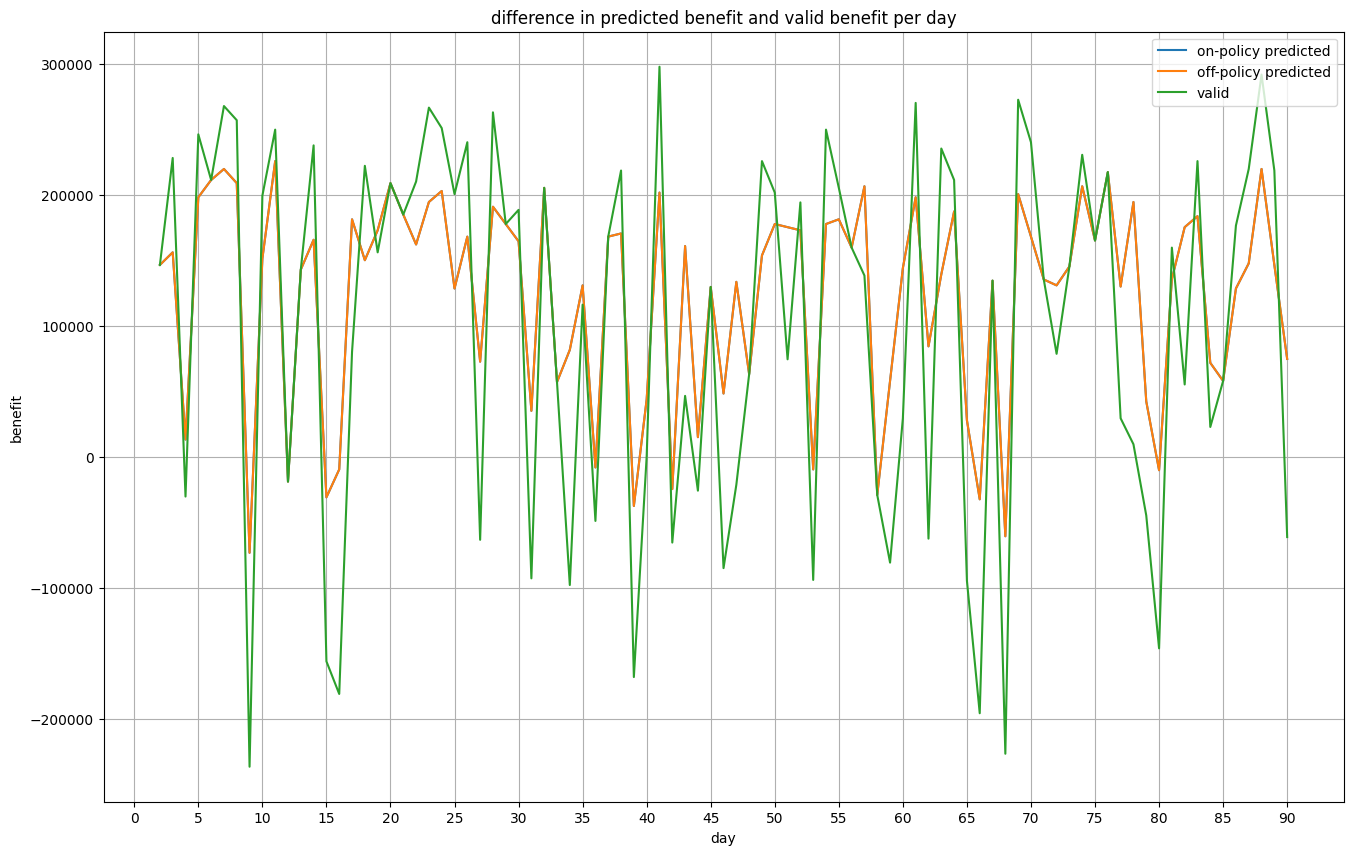

In [16]:
plt.figure(figsize=(16, 10))
plt.plot(range(2, len(on_policy_predicted_reward_list)+2),
         on_policy_predicted_reward_list,
         label="on-policy predicted")
plt.plot(range(2, len(off_policy_predicted_reward_list)+2),
         off_policy_predicted_reward_list,
         label="off-policy predicted")
plt.plot(range(2, len(valid_reward_list)+2),
         valid_reward_list,
         label="valid")
plt.title(label="difference in predicted benefit and valid benefit per day")
plt.xlabel(xlabel="day")
plt.xticks(ticks=np.arange(0, len(valid_reward_list)+2, 5))
plt.ylabel(ylabel="benefit")
plt.legend(loc="upper right")
plt.grid(visible=True)
plt.show()